In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sahilhussain2410/ev-simulation-ds/simulation_ds/pricing_report.csv
/kaggle/input/datasets/sahilhussain2410/ev-simulation-ds/simulation_ds/tariffs.csv
/kaggle/input/datasets/sahilhussain2410/ev-predction/ev_predictions/demand_predictions_valid.csv
/kaggle/input/datasets/sahilhussain2410/ev-predction/ev_predictions/demand_predictions.csv
/kaggle/input/datasets/sahilhussain2410/test-df-simulation/test_df.csv
/kaggle/input/datasets/sahilhussain2410/ev-dataset-model/model_data.csv


In [2]:
test_df=pd.read_csv('/kaggle/input/datasets/sahilhussain2410/test-df-simulation/test_df.csv')

In [3]:
tariffs = pd.read_csv(
    "/kaggle/input/datasets/sahilhussain2410/ev-simulation-ds/simulation_ds/tariffs.csv",
    parse_dates=["time"]
)

In [4]:
sim_df=test_df.copy()

# customer response rate

In [5]:
customer_response_rate = (
    (
        sim_df["adjusted_demand"].sum()
        -
        sim_df["predicted_demand"].sum()
    )
    /
    sim_df["predicted_demand"].sum()
) * 100

In [6]:
print(
    f"Customer Response Rate: {customer_response_rate:.2f}%"
)

Customer Response Rate: -0.52%


# cogestion reduction

In [7]:
baseline_congestion = (
    sim_df["predicted_utilization"] > 0.60
).sum()

In [8]:
dynamic_congestion = (
    sim_df["new_utilization"] > 0.60
).sum()

congestion_reduction = (
    (
        baseline_congestion -
        dynamic_congestion
    )
    /
    baseline_congestion
) * 100

In [9]:
print(
    f"Congestion Reduction: {congestion_reduction:.2f}%"
)

Congestion Reduction: 85.14%


# Waiting Time Simulation

In [10]:
# assume
BASE_WAIT = 10

In [11]:
sim_df["baseline_wait"] = (
    BASE_WAIT *
    (
        sim_df["predicted_utilization"]
        /
        0.50
    )
)

In [12]:
sim_df["dynamic_wait"] = (
    BASE_WAIT *
    (
        sim_df["new_utilization"]
        /
        0.50
    )
)

In [13]:
sim_df["baseline_wait"] = (
    sim_df["baseline_wait"]
    .clip(lower=0)
)

sim_df["dynamic_wait"] = (
    sim_df["dynamic_wait"]
    .clip(lower=0)
)

# waiting time reduction

In [14]:
waiting_reduction = (
    (
        sim_df["baseline_wait"].mean()
        -
        sim_df["dynamic_wait"].mean()
    )
    /
    sim_df["baseline_wait"].mean()
) * 100

In [15]:
print(
    f"Waiting Time Reduction: {waiting_reduction:.2f}%"
)

Waiting Time Reduction: -3.58%


# pricing efficiency score

In [16]:
baseline_efficiency = (
    sim_df["baseline_revenue"].sum()
    /
    sim_df["predicted_demand"].sum()
)
dynamic_efficiency = (
    sim_df["dynamic_revenue"].sum()
    /
    sim_df["adjusted_demand"].sum()
)
pricing_efficiency_gain = (
    (
        dynamic_efficiency
        -
        baseline_efficiency
    )
    /
    baseline_efficiency
) * 100

# SIMULATION

In [17]:
elasticities = [
    -0.3,
    -0.5,
    -0.8,
    -1.0
]
scenario_results = []

In [18]:
for e in elasticities:

    demand_adj = (
        sim_df["predicted_demand"]
        *
        (
            1 +
            e *
            (
                sim_df["dynamic_price"]/15 - 1
            )
        )
    )

    demand_adj = demand_adj.clip(
        lower=0
    )

    revenue = (
        demand_adj
        *
        sim_df["dynamic_price"]
    ).sum()

    revenue_gain = (
        (
            revenue
            -
            sim_df["baseline_revenue"].sum()
        )
        /
        sim_df["baseline_revenue"].sum()
    ) * 100

    scenario_results.append([
        e,
        revenue_gain
    ])

In [19]:
scenario_df = pd.DataFrame(
    scenario_results,
    columns=[
        "elasticity",
        "revenue_gain_pct"
    ]
)

# Monitoring agent recommendation

In [20]:
def recommend_update(
    revenue_gain,
    congestion_reduction
):

    if revenue_gain < 2:

        return (
            "Increase surge coefficient"
        )

    elif congestion_reduction < 5:

        return (
            "Increase discount coefficient"
        )

    else:

        return (
            "Current pricing acceptable"
        )

In [21]:
revenue_gain_pct=0.44

In [22]:
recommendation = (
    recommend_update(
        revenue_gain_pct,
        congestion_reduction
    )
)

In [23]:
offpeak_uplift=2.17


In [24]:
metrics = pd.DataFrame({

    "Metric":[
        "Revenue Gain %",
        "Off Peak Uplift %",
        "Customer Response Rate %",
        "Congestion Reduction %",
        "Waiting Time Reduction %",
        "Pricing Efficiency Gain %"
    ],

    "Value":[
        revenue_gain_pct,
        offpeak_uplift,
        customer_response_rate,
        congestion_reduction,
        waiting_reduction,
        pricing_efficiency_gain
    ]
})

In [25]:
metrics.to_csv(
    "metrics.csv",
    index=False
)

<Axes: >

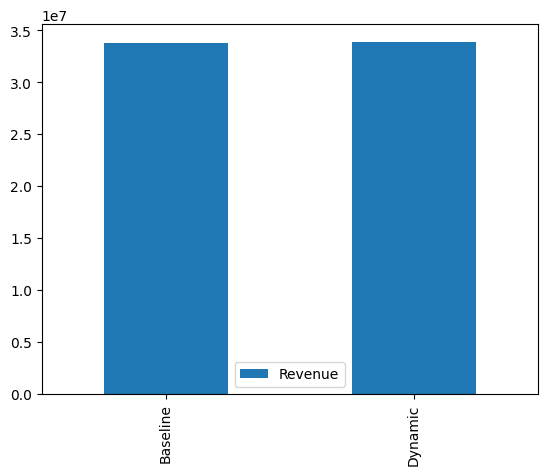

In [26]:
pd.DataFrame({

    "Revenue":[
        sim_df["baseline_revenue"].sum(),
        sim_df["dynamic_revenue"].sum()
    ]

}, index=[
    "Baseline",
    "Dynamic"
]).plot(
    kind="bar"
)

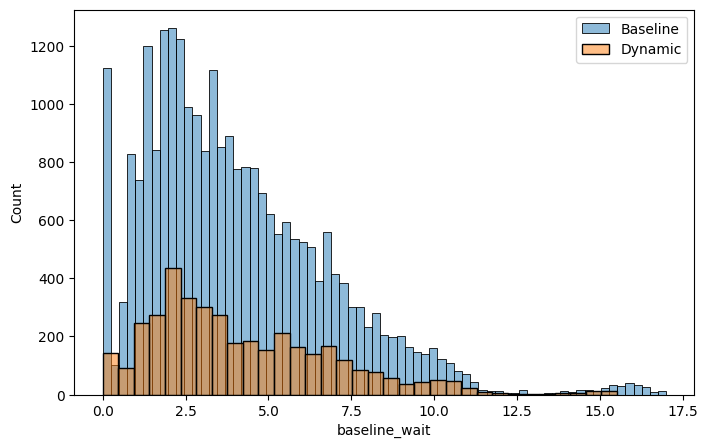

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))

sns.histplot(
    sim_df["baseline_wait"],
    label="Baseline",
    alpha=0.5
)

sns.histplot(
    sim_df["dynamic_wait"],
    label="Dynamic",
    alpha=0.5
)

plt.legend()
plt.show()

In [28]:
metrics

,Metric,Value
0,Revenue Gain %,0.440000
1,Off Peak Uplift %,2.170000
2,Customer Response Rate %,-0.517885
3,Congestion Reduction %,85.139319
4,Waiting Time Reduction %,-3.582611
5,Pricing Efficiency Gain %,0.957875
